# 変数の中で似たような動きをしているものは？

環境データや生態データでは、複数の変数を同時に観測することが一般的である。
しかし、すべての変数が「独立した情報」を持っているとは限らない。

例えば、

- 水温が高いと溶存酸素（DO）が低くなりやすい
- pH と Eh は酸化還元状態を通じて関係することがある

といったように、**物理・化学的な理由によって連動する変数**が存在する。

このような「似た動きをする変数」を把握することには、次のような意味がある。

- 情報の重複を理解できる（変数を減らせる可能性）
- 背後にある共通因子（温度・酸化還元状態など）を推測できる
- 次元削減や主成分分析（PCA）への準備になる

ここでは、
**「どの変数が、どの程度似た動きをしているのか」**
を、可視化と数値の両面から確認する。

## 自作パッケージを使う準備

このノートブックでは、自作パッケージ `myutils` を使用する。

- `myutils/`
- `pyproject.toml`

はセットで必要であり、これらはこのノートブックがある場所の
2つ上のディレクトリに置いておかなければならない。
（ディレクトリの位置関係（ディレクトリ構造）は
GitHubの状態と一緒にしておいてください。）

### myutils とは？

`myutils` は、この授業用に作成した自作の Python パッケージである。

中には、

- CSV ファイルを安全に読み込む関数
- 必要な列だけを選ぶ関数
- 図の見た目を整える関数
- 散布図を簡単に描く関数

など、解析の本質ではないが頻繁に使う処理をまとめている。

```text
myutils/
├── io.py    ← データの読み込み関連
├── viz.py   ← 図の描画・スタイル設定
├── stats.py ← 統計処理（必要に応じて）
```
### pyproject.toml とは？

`pyproject.toml` は、
「このプロジェクトには、どんな Python パッケージが含まれているか」
を Python に伝えるための設定ファイル。

このファイルがあることで、ノートブックから自作 Python パッケージ（myutils）を読み込むことができるようになる。
このファイルがあることで、以下のコマンドで myutils を読み込む準備が整う。

```python
%pip install -e "../.."
```
> `-e` = editable  → ソースコードを書き換えたら即反映

In [1]:
%pip install -e "../.."

Obtaining file:///Users/seto/Documents/GitHub/tuat-python-seminar-2025/notebooks
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for myutils (pyproject.toml) ... done
  Created wheel for myutils: filename=myutils-0.1.0-0.editable-py3-none-any.whl size=2822 sha256=10148516828cd6b1000a0f272a7ed8bb16cbe9ac98ab38878fba8415a3bc0b45
  Stored in directory: /private/var/folders/6c/xqlg21kx37lbykmsw_xwyx500000gn/T/pip-ephem-wheel-cache-zim78k60/wheels/ad/13/ce/0eebbfe8f8d26b7a8284ecb27fad3010718ecae8e6199e111b
Successfully built myutils
  Attempting uninstall: myutils
    Found existing installation: myutils 0.1.0
    Uninstalling myutils-0.1.0:
      Successfully uninstalled myutils-0.1.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import myutils, sys
print("myutils:", myutils.__file__)
print("python:", sys.executable)

from myutils import safe_read_csv, select_columns, apply_pub_style, plot_scatter


# 共通スタイルを一括適用（任意）
apply_pub_style()

myutils: /Users/seto/Documents/GitHub/tuat-python-seminar-2025/notebooks/myutils/__init__.py
python: /Users/seto/miniforge3/envs/py312/bin/python


### `import myutils` と `from myutils import ...` の違い

ここでは、同じ `myutils` パッケージに対して、
2種類の import を使っている。

```python
import myutils, sys
```

この書き方では、
myutils という 名前空間（namespace）が作られ、
中の関数や変数は
myutils.apply_pub_style() のように呼び出す。

この形式の利点は、

- どの関数がどのパッケージ由来かが明確
- そのため、デバッグや確認に向いている

```python
from myutils import safe_read_csv, select_columns, apply_pub_style, plot_scatter
```

この書き方では、指定した関数だけを現在の名前空間に直接読み込む。
その結果、上記のように apply_pub_style() という関数名だけで利用できるようになる。


## 散布図（まず“見る”）

多変量解析に入る前に、必ず生データを可視化することが重要。

散布図を見ることで、

- 直線的な関係がありそうか
- 外れ値が存在するか
- 非線形な構造がありそうか

といった情報を、人間の直感で把握できる。

また、視覚情報を得ることで、後で計算される相関係数や行列操作が、
「何を要約しているのか」を理解することにも役立つ。

In [3]:
# 1) 安全に読み込み
DATA_PATH = Path("Morimoto_et_al_SI_A1.csv")
df = safe_read_csv(DATA_PATH)

# 2) 欲しい列だけ抽出（存在しない列は自動で落ちる）
cols_selected = ["Temperature", "pH", "EC (É\xa0S/cm)", "DO (mg/L)", "Eh (mV vs. SHE)"]
df = select_columns(df, cols_selected)

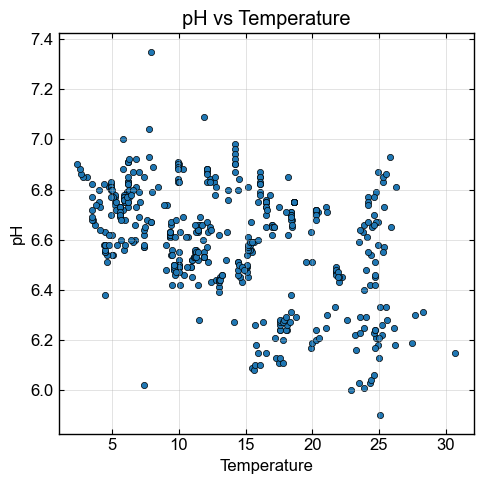

In [5]:
# 3) myutilsのplot_scatterを用いて可視化する。
# plot_scatterはデータフレームdfのカラム名で2列を指定する。
plot_scatter(df, "Temperature", "pH");

# 以下はcols_selectedの要素数を指定し、x_name, y_nameを得て可視化する場合。
# x_name, y_name = cols_selected[1], cols_selected[2]  # Temperature vs pH
# plot_scatter(df, x_name, y_name)

## 多変量データを一望する（pair plot）

2変数の散布図は理解しやすいが
データの変数が多い場合にいちいち散布図を作るのは面倒。

ここではデータ可視化ライブラリ seaborn の pair plot を用いて、

- すべての変数ペアの散布図
- 各変数の分布（対角成分）

を一度に確認する。

これにより、

- 「どの変数同士が似た動きをしていそうか」
- 「強い相関がありそうな組み合わせはどれか」

を直感的に把握することができる。

['Temperature', 'pH', 'EC (É\xa0S/cm)', 'DO (mg/L)', 'Eh (mV vs. SHE)']


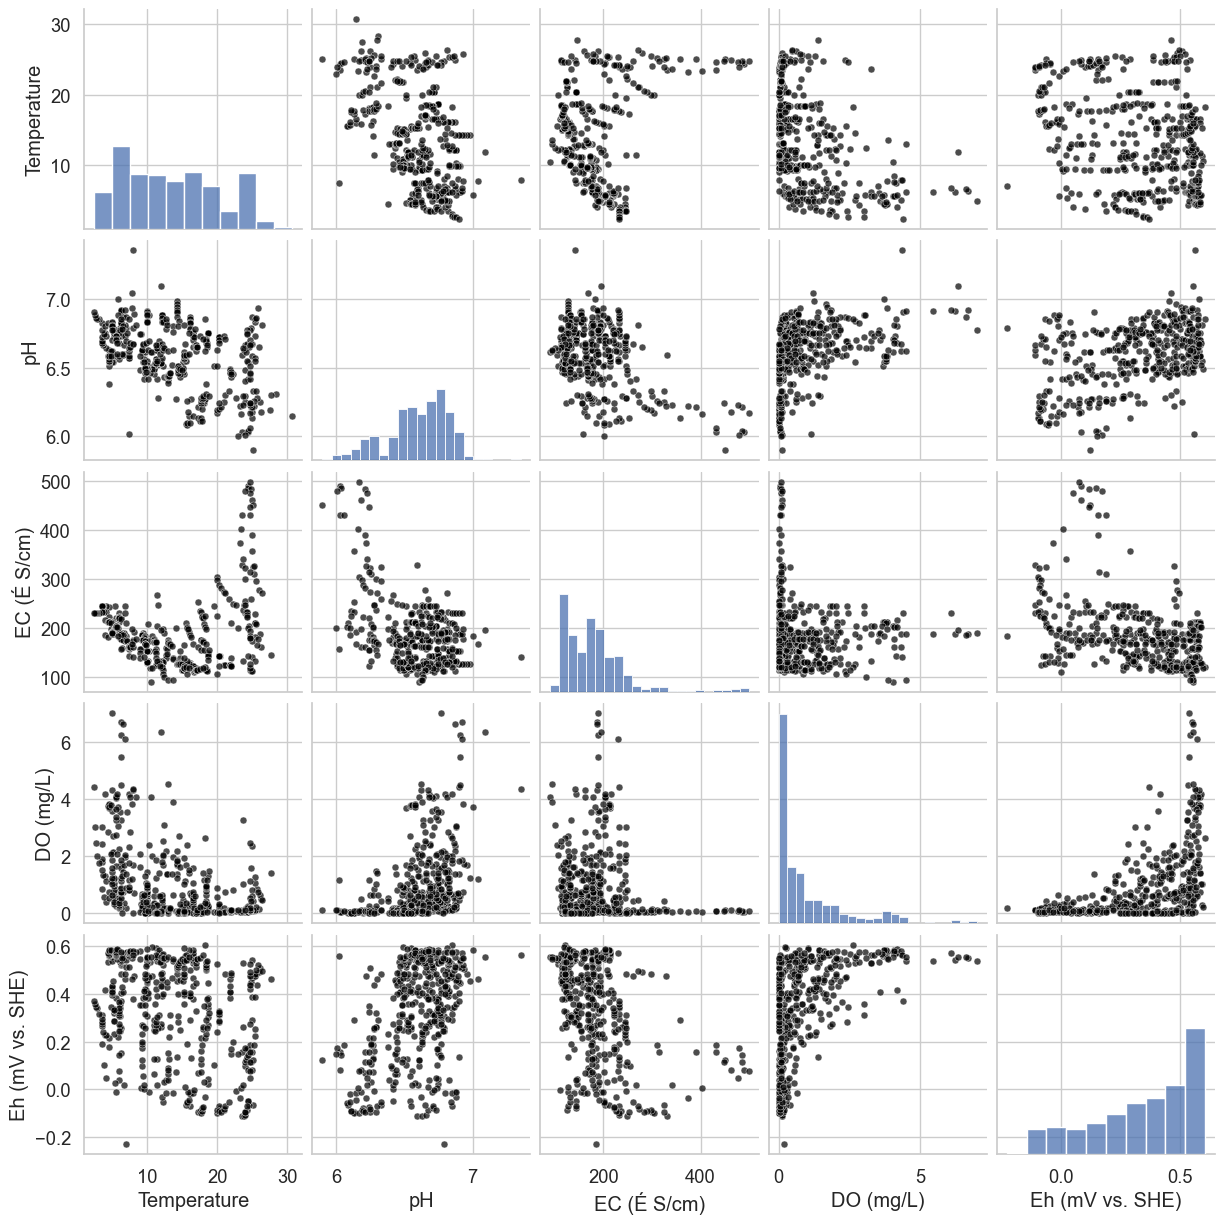

In [10]:
import seaborn as sns
sns.set_theme(style="whitegrid", font="Arial", font_scale=1.2)

print(cols_selected)
for c in cols_selected:
    df[c] = pd.to_numeric(df[c], errors="coerce")

sns.pairplot(df[cols_selected], diag_kind="hist", plot_kws=dict(s=25, color="black", alpha=0.7))
plt.show()

## 相関係数とは何を測っているのか？

2つの変数 $(x, y)$ の ピアソン相関係数 は次で定義されます。

$$
r_{xy}
=
\frac{\mathrm{cov}(x, y)}{\sigma_x \sigma_y}
=
\frac{1}{n-1}
\sum_{i=1}^{n}
\left(
\frac{x_i - \bar{x}}{\sigma_x}
\right)
\left(
\frac{y_i - \bar{y}}{\sigma_y}
\right)
$$

この値は、

- $r = 1$：完全に同じ方向に動く
- $r = -1$：完全に逆方向に動く
- $r = 0$：線形な関係がない

ことを意味する。

つまり相関係数とは、
「2つの変数がどれだけ一緒に増減するか」
を数値化した指標である。


以下はdf[cols_selected]について相関係数行列を得る。

In [11]:
# df のうち、cols_selected に含まれる列だけを取り出し、
# それぞれを数値に変換し、変換できないものは NaN にする。
df_num = df[cols_selected].apply(pd.to_numeric, errors="coerce")  # 数値化

# DataFrame の各列同士について、
# ピアソン相関係数を計算し、
# 相関係数行列（正方行列）を返す
corr = df_num.corr(method="pearson")  # "spearman" も選べます
corr

,Temperature,pH,EC (É S/cm),DO (mg/L),Eh (mV vs. SHE)
Temperature,1.000000,-0.458887,0.176787,-0.448351,-0.305541
pH,-0.458887,1.000000,-0.437414,0.400778,0.436351
EC (É S/cm),0.176787,-0.437414,1.000000,-0.052004,-0.444230
DO (mg/L),-0.448351,0.400778,-0.052004,1.000000,0.495781
Eh (mV vs. SHE),-0.305541,0.436351,-0.444230,0.495781,1.000000


### 相関行列の見方

相関行列は、すべての変数ペアについて相関係数を計算したものである。

- 対角成分は常に 1（自分自身との相関）
- 行列は対称（$r_{ij} = r_{ji}$）

この行列は、
「多変量データに含まれる関係性を、1枚の行列に圧縮したもの」
と考えることができる。

後に紹介する主成分分析（PCA）では、
この相関行列（または共分散行列）に対して
線形代数の操作（固有値問題）を行う。

### 相関行列を色で読む

相関行列を数値だけで比較するのは不便。
そこで、色を使って相関の強さと符号を可視化する。

- 赤系：正の相関（同じ方向に動く）
- 青系：負の相関（逆方向に動く）
- 白付近：相関が弱い

この図から、
「似た振る舞いをする変数のグループ」
を視覚的に探すことができる。


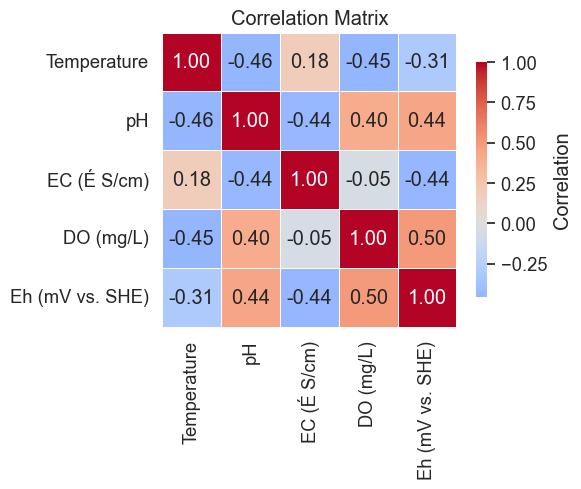

In [12]:
sns.set_theme(style="whitegrid", font="Arial", font_scale=1.2)

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True,          # 各セルに数値を表示
    fmt=".2f",           # 小数点以下2桁
    cmap="coolwarm",     # 色マップ（他に "vlag", "RdBu_r" など）
    center=0,            # 0 を白で中央に
    square=True,         # セルを正方形に
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Correlation"},
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### なぜ相関係数を計算する前に散布図を見るのか？

相関係数は、2つの変数の関係を1つの数値に要約する便利な指標だが、
その便利さゆえに、重要な情報を見落とす可能性もある。

☑️ 可能性その１：非線形関係を見落とす

ピアソン相関係数は、「2つの変数が直線的に一緒に増減しているか」を測る指標であるため、

- 曲線的な関係（U字型など）
- 閾値を境に挙動が変わる関係

これらは、強い関係があっても相関係数が 0 に近くなることがある。

☑️ 可能性その２：外れ値に引きずられた判断をしてしまう

- ほとんどの点は関係が弱い
- しかし、1点の極端な値がある

ような場合でも、
相関係数は「強い相関がある」と判断してしまうことがある。

散布図を見ることで、

- 外れ値が存在するか
- 相関が一部の点に引っ張られていないか

を直感的に確認できます。

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 再現性のため乱数の種を固定
np.random.seed(0)

# x を -3 から 3 の範囲で生成
x = np.linspace(-3, 3, 100)

# y は x^2 に小さなノイズを加えたもの（U字型）
y = x**2 + np.random.normal(scale=0.5, size=len(x))

df_u = pd.DataFrame({"x": x, "y": y})
df_u.head()

,x,y
0,-3.000000,9.882026
1,-2.939394,8.840115
2,-2.878788,8.776789
3,-2.818182,9.062595
4,-2.757576,8.538003


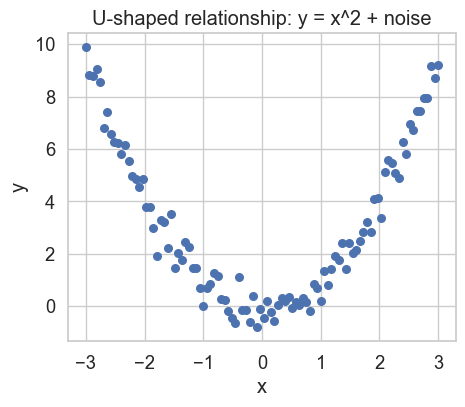

In [14]:
plt.figure(figsize=(5, 4))
plt.scatter(df_u["x"], df_u["y"], s=30)
plt.xlabel("x")
plt.ylabel("y")
plt.title("U-shaped relationship: y = x^2 + noise")
plt.grid(True)
plt.show()

In [15]:
df_u.corr(method="pearson")

,x,y
x,1.000000,-0.014593
y,-0.014593,1.000000


## 相関以外で 2 つのデータの関係を捉える方法は？

### 1. 非線形な関係を見る

散布図で見た U 字型の例のように、
変数間の関係が直線ではない場合がある。

このような場合には、

- 多項式回帰
- スプライン
- 局所回帰（LOESS）

など、「関係の形」を直接モデル化する方法が使われる。



### 2. 順位や単調性に注目する

ピアソン相関は「値そのもの」を使うが、
順位だけに注目する考え方もある。

- Spearman 相関
- Kendall の順位相関

これらは、

- 値の分布に強く依存しない
- 外れ値の影響を受けにくい

という特徴がある。

「増えれば増える」「減れば減る」といった
**単調な関係**を捉えたいときに有効。

### 3. 情報量という観点から関係を見る

より発展的な考え方として、

- 相互情報量（Mutual Information）

がある。

これは、「一方の変数を知ることで、もう一方についてどれだけ情報が増えるか」を測る指標で、線形・非線形を問わず関係を捉えられる可能性がある。

ただし、計算や解釈はやや高度。

### 4. 相関と因果は別の概念

最後に重要な点として、

- 相関がある ＝ 因果関係がある

とは限らない。
（相関 ≠ 因果に関しては森本響子(2025)修士論文を読んでください、まだ執筆中）

時間情報や構造を考慮することで、
「どちらがどちらに影響しているのか（因果関係）」
を議論する枠組みも存在するが、相関とは別次元の問い。
